In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')  

In [2]:
# Load air quality dataset
airquality_dataset = pd.read_csv('../data/raw/AirQualityData.csv')

Analyzing Feature: PM2.5
Skewness: -0.0453


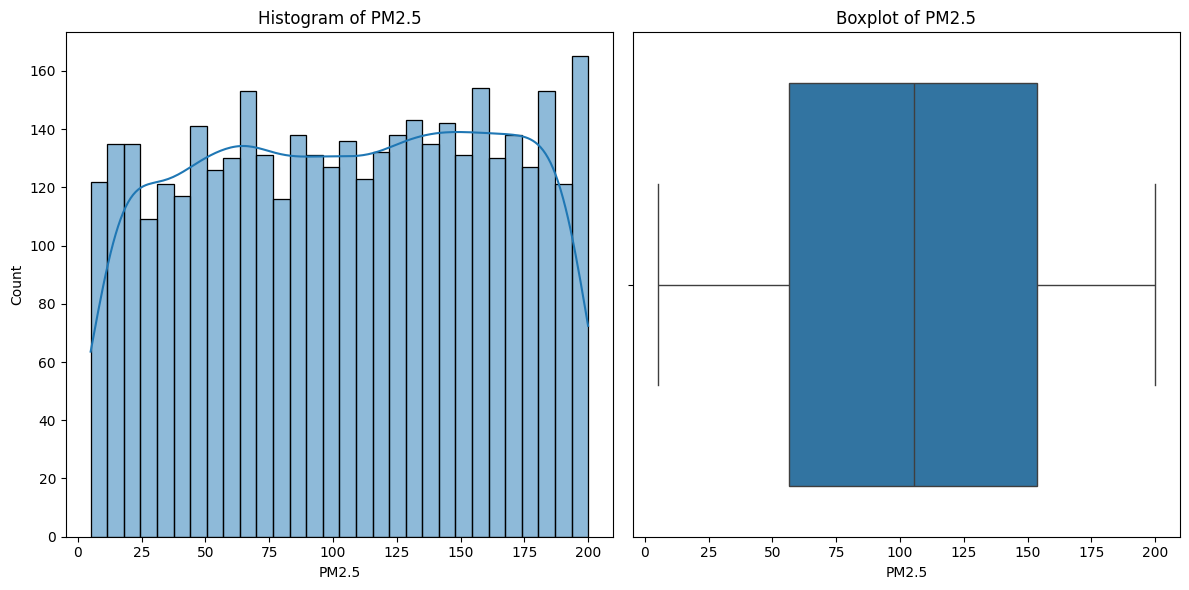

Analyzing Feature: PM10
Skewness: 0.0034


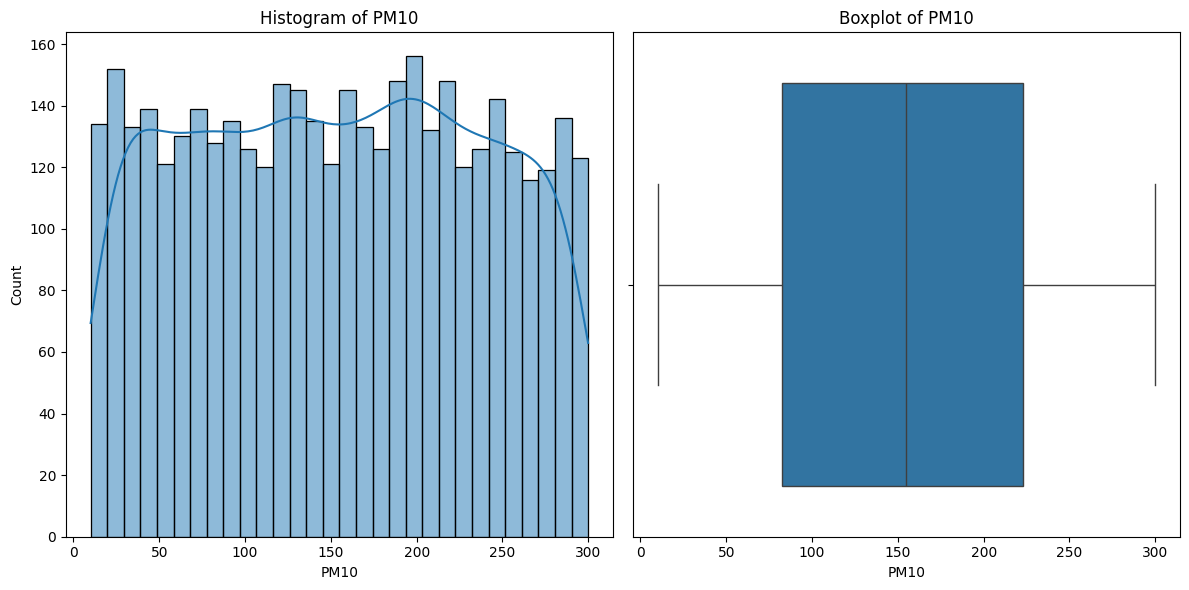

Analyzing Feature: Temperature
Skewness: 0.0376


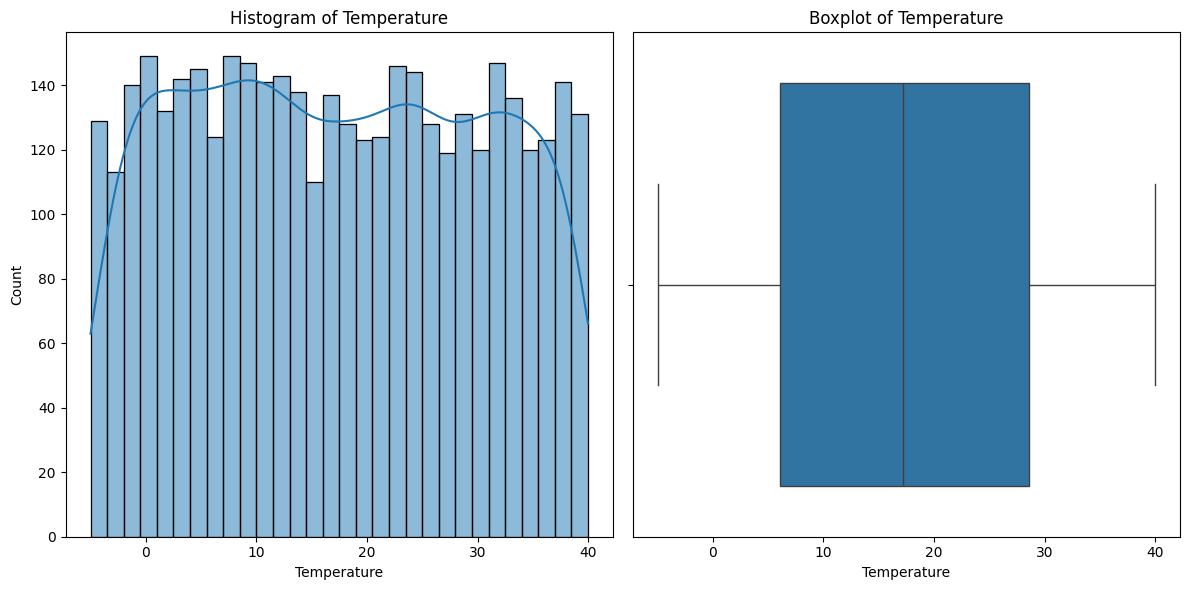

Analyzing Feature: Humidity
Skewness: 0.0037


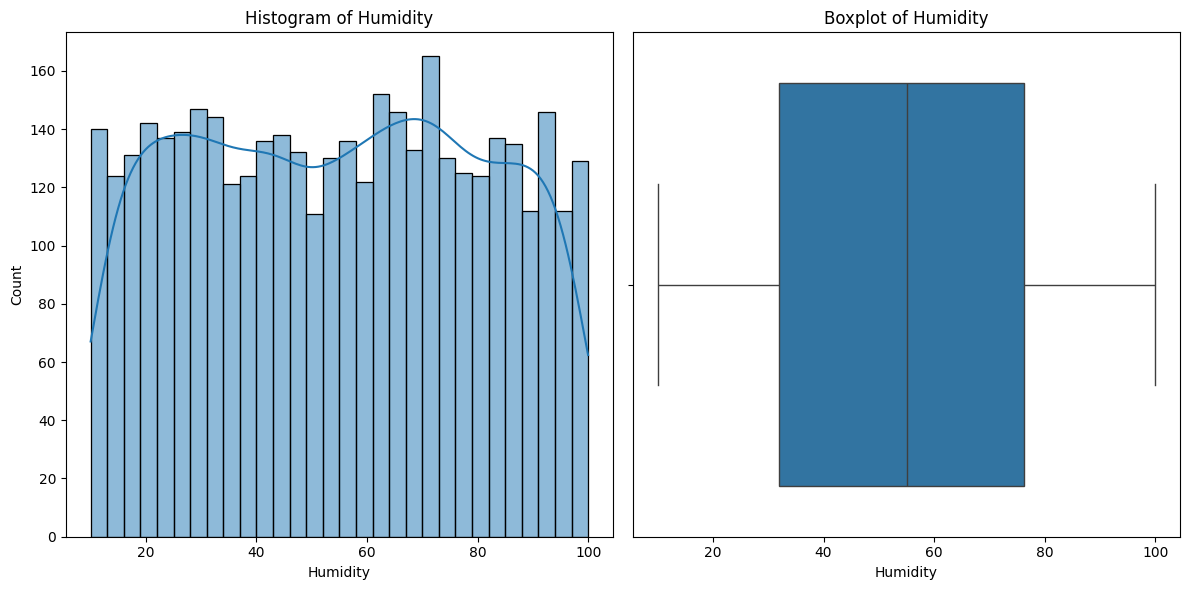

Analyzing Feature: Pressure
Skewness: 0.0055


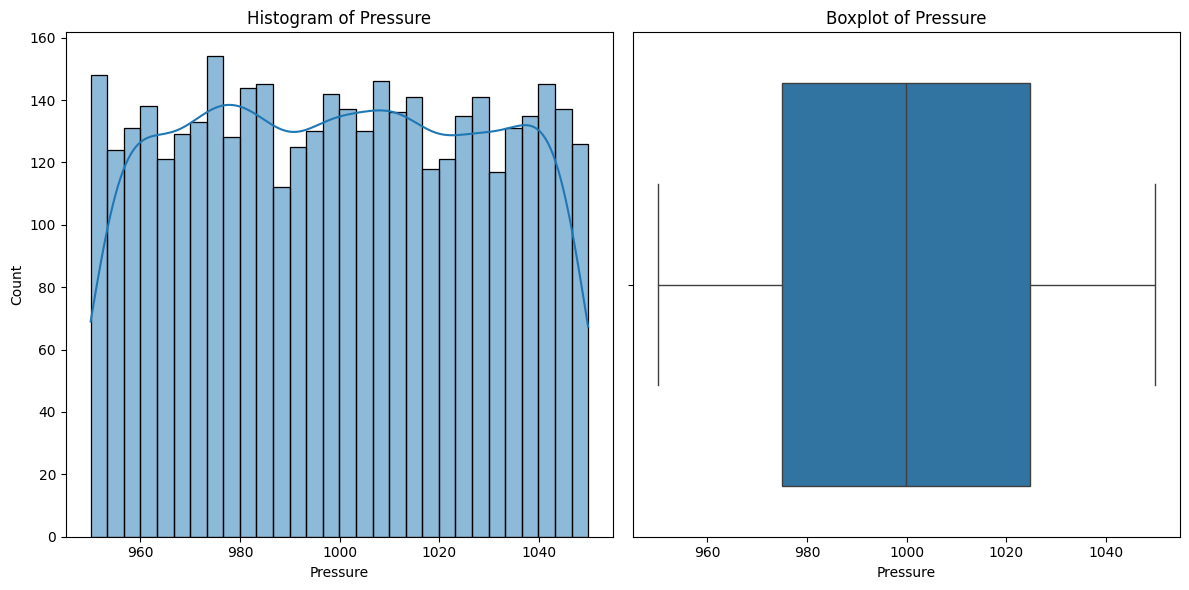

Analyzing Feature: AirQualityIndex
Skewness: -0.0130


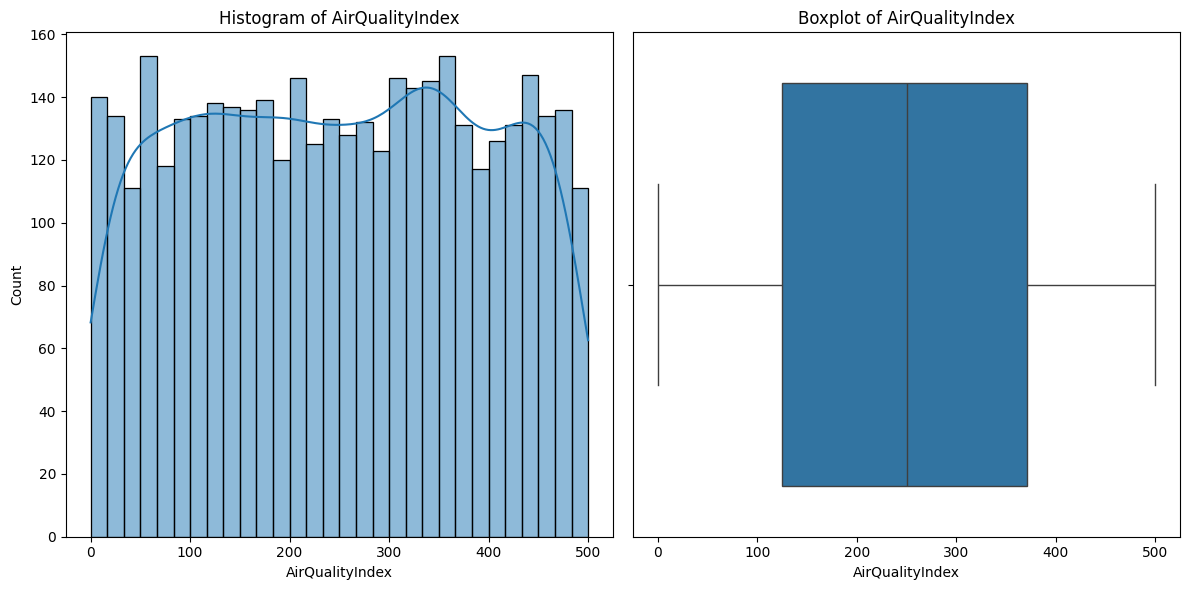

In [3]:
import seaborn as sns
from scipy.stats import skew
import matplotlib.pyplot as plt
import numpy as np

# Function to perform univariate analysis
def univariate_analysis(df, columns=None):
    # If no columns are provided, analyze all numeric columns
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns

    for column in columns:
        print(f"Analyzing Feature: {column}")

        # Calculate skewness
        skewness = skew(df[column].dropna())
        print(f"Skewness: {skewness:.4f}")

        # Plot histogram
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.histplot(df[column], kde=True, bins=30)
        plt.title(f"Histogram of {column}")

        # Plot boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[column])
        plt.title(f"Boxplot of {column}")

        plt.tight_layout()
        plt.show()

# Perform univariate analysis on airquality_dataset
airquality_features = ["PM2.5", "PM10", "Temperature", "Humidity", "Pressure", "AirQualityIndex"]
univariate_analysis(airquality_dataset, airquality_features)

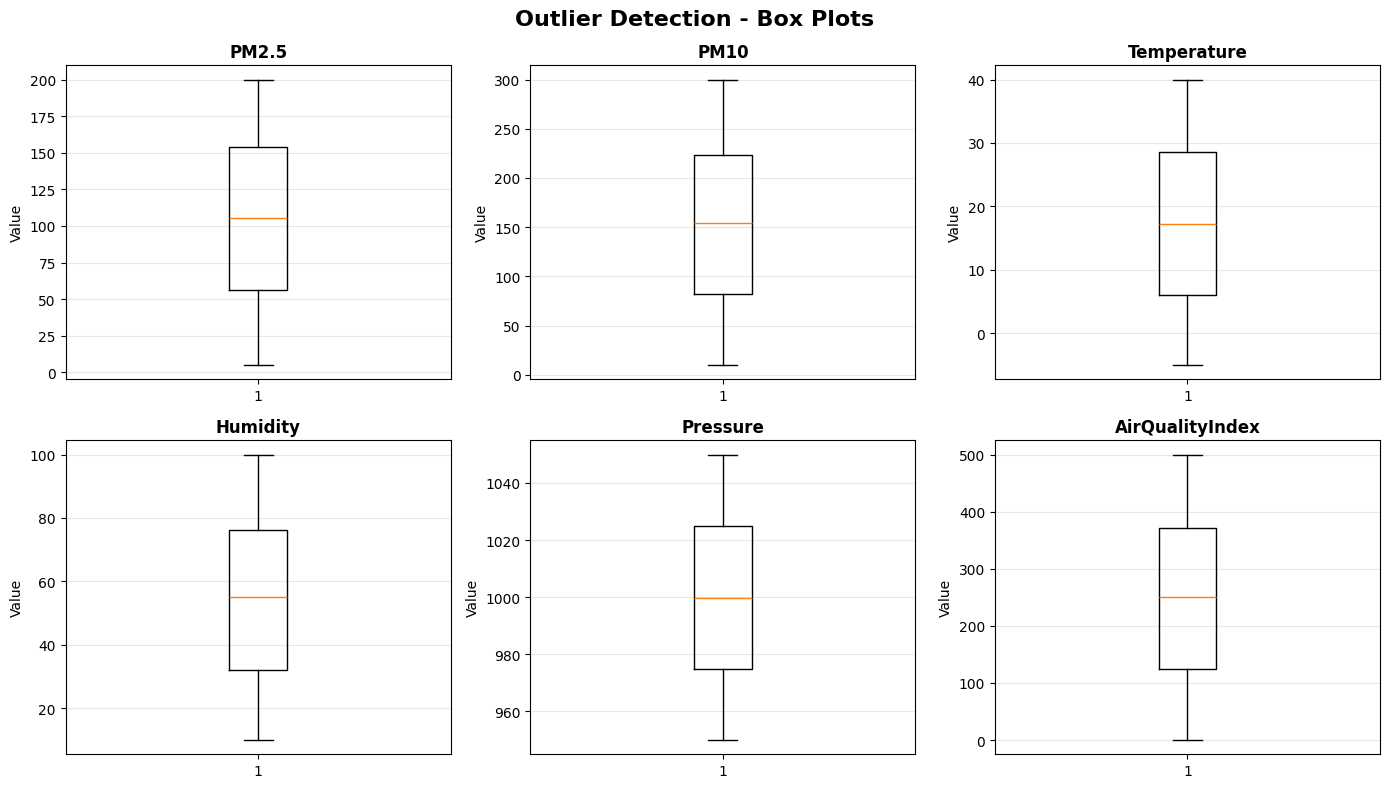

Outlier analysis complete


In [5]:
# Outlier Detection Box Plots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Outlier Detection - Box Plots', fontsize=16, fontweight='bold')

features = ['PM2.5', 'PM10', 'Temperature', 'Humidity', 'Pressure', 'AirQualityIndex']
axes = axes.flatten()

for idx, feature in enumerate(features):
    axes[idx].boxplot(airquality_dataset[feature], vert=True)
    axes[idx].set_title(f'{feature}', fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Outlier analysis complete")

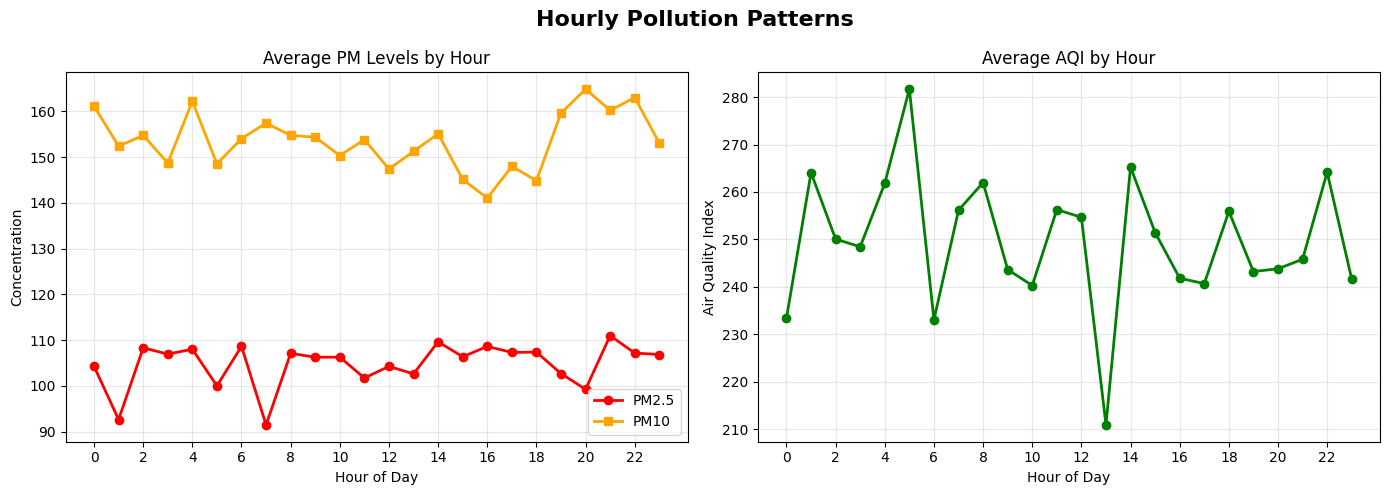

Hourly pattern analysis complete


In [6]:
# Temporal Pattern Analysis: Hourly patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hourly Pollution Patterns', fontsize=16, fontweight='bold')

# PM2.5 and PM10 by hour of day
hourly_pm = airquality_dataset.groupby('Hour')[['PM2.5', 'PM10']].mean()
axes[0].plot(hourly_pm.index, hourly_pm['PM2.5'], marker='o', label='PM2.5', linewidth=2, color='red')
axes[0].plot(hourly_pm.index, hourly_pm['PM10'], marker='s', label='PM10', linewidth=2, color='orange')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Concentration')
axes[0].set_title('Average PM Levels by Hour')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# AirQualityIndex by hour of day
hourly_aqi = airquality_dataset.groupby('Hour')['AirQualityIndex'].mean()
axes[1].plot(hourly_aqi.index, hourly_aqi.values, marker='o', linewidth=2, color='green')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Air Quality Index')
axes[1].set_title('Average AQI by Hour')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

print("Hourly pattern analysis complete")

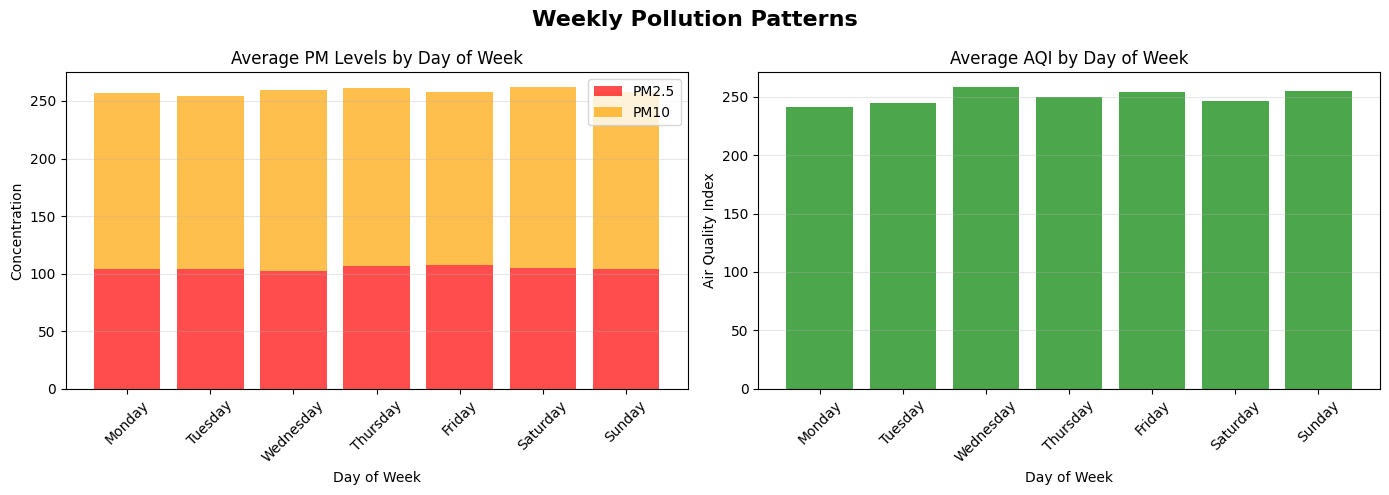

Weekly pattern analysis complete


In [7]:
# Daily Pattern Analysis: Day of Week patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Weekly Pollution Patterns', fontsize=16, fontweight='bold')

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# PM2.5 and PM10 by day of week
daily_pm = airquality_dataset.groupby('DayOfWeek')[['PM2.5', 'PM10']].mean()
axes[0].bar(range(7), daily_pm['PM2.5'], label='PM2.5', alpha=0.7, color='red')
axes[0].bar(range(7), daily_pm['PM10'], label='PM10', alpha=0.7, color='orange', bottom=daily_pm['PM2.5'])
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Concentration')
axes[0].set_title('Average PM Levels by Day of Week')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names, rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# AirQualityIndex by day of week
daily_aqi = airquality_dataset.groupby('DayOfWeek')['AirQualityIndex'].mean()
axes[1].bar(range(7), daily_aqi.values, color='green', alpha=0.7)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Air Quality Index')
axes[1].set_title('Average AQI by Day of Week')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names, rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Weekly pattern analysis complete")

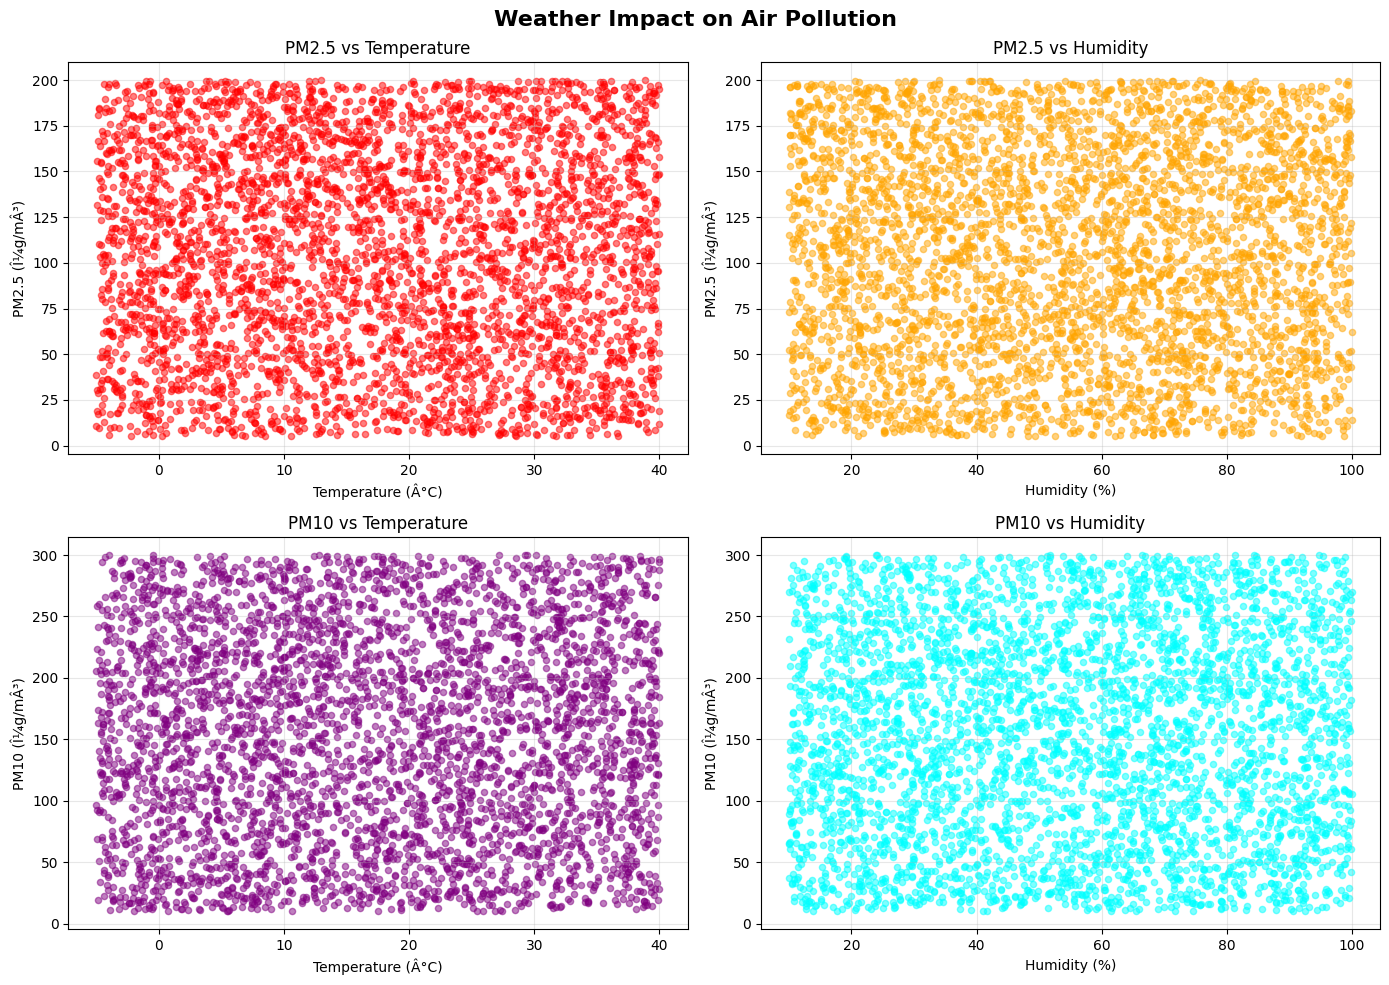

Weather impact analysis complete


In [8]:
# Weather Impact Analysis: Scatter Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weather Impact on Air Pollution', fontsize=16, fontweight='bold')

# PM2.5 vs Temperature
axes[0, 0].scatter(airquality_dataset['Temperature'], airquality_dataset['PM2.5'], 
                   alpha=0.5, s=20, color='red')
axes[0, 0].set_xlabel('Temperature (Â°C)')
axes[0, 0].set_ylabel('PM2.5 (Î¼g/mÂ³)')
axes[0, 0].set_title('PM2.5 vs Temperature')
axes[0, 0].grid(True, alpha=0.3)

# PM2.5 vs Humidity
axes[0, 1].scatter(airquality_dataset['Humidity'], airquality_dataset['PM2.5'], 
                   alpha=0.5, s=20, color='orange')
axes[0, 1].set_xlabel('Humidity (%)')
axes[0, 1].set_ylabel('PM2.5 (Î¼g/mÂ³)')
axes[0, 1].set_title('PM2.5 vs Humidity')
axes[0, 1].grid(True, alpha=0.3)

# PM10 vs Temperature
axes[1, 0].scatter(airquality_dataset['Temperature'], airquality_dataset['PM10'], 
                   alpha=0.5, s=20, color='purple')
axes[1, 0].set_xlabel('Temperature (Â°C)')
axes[1, 0].set_ylabel('PM10 (Î¼g/mÂ³)')
axes[1, 0].set_title('PM10 vs Temperature')
axes[1, 0].grid(True, alpha=0.3)

# PM10 vs Humidity
axes[1, 1].scatter(airquality_dataset['Humidity'], airquality_dataset['PM10'], 
                   alpha=0.5, s=20, color='cyan')
axes[1, 1].set_xlabel('Humidity (%)')
axes[1, 1].set_ylabel('PM10 (Î¼g/mÂ³)')
axes[1, 1].set_title('PM10 vs Humidity')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Weather impact analysis complete")